# 01 — Load & Explore the NFL Play-by-Play Data

**Goal of this notebook:** load all three seasons of data, get a feel for what's in it, and spot problems (null columns, weird play types) BEFORE we start cleaning.

This is always step one in a data project: *look at your data before you touch it.*

**The three data sources** (all free, from nflverse):
1. **Play-by-play** — every row is one play (2023–2025), ~372 columns: situation (down, distance, score...), the play itself, and advanced metrics like **EPA** (Expected Points Added — how much a play improved your scoring outlook).
2. **Participation** — formation, personnel grouping (e.g. "1 RB, 1 TE, 3 WR"), defenders in box, coverage type.
3. **FTN charting** — hand-charted flags: play action, screens, RPOs, motion, blitzers, QB alignment.

## Setup

The notebook lives in `notebooks/` but our code lives in `src/`, so we add the project root to Python's import path. Then we import our loader plus the usual data-science tools.

In [1]:
import os
import sys

# Add the project root (one folder up from notebooks/) to the import path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_data

# Make charts a consistent, readable size
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Setup complete')

Setup complete


## Load the data

`load_data()` does four things:
1. Reads every `play_by_play_*.csv(.gz)` file in `data/raw/` and stacks them.
2. Reads the `participation_*.csv` files (formation, personnel, coverage).
3. Reads the `ftn_charting_*.csv` files (play action, screens, RPO...).
4. Left-joins everything on `(game_id, play_id)` so every play keeps its row — plays the charters didn't cover just get NaN in those columns.

This takes ~30–60 seconds — the play-by-play files alone have 372 columns each.

In [2]:
df = load_data()

LOADING DATA
Loading play_by_play_2023.csv.gz ...
Loading play_by_play_2024.csv.gz ...
Loading play_by_play_2025.csv.gz ...
Loading participation_2023.csv ...
Loading participation_2024.csv ...
Loading participation_2025.csv ...
Loading ftn_charting_2023.csv ...
Loading ftn_charting_2024.csv ...
Loading ftn_charting_2025.csv ...
Participation data matched on 109,717 of 147,928 plays.
FTN charting matched on 143,572 of 147,928 plays.
------------------------------------------------------------
Combined shape : 147,928 rows x 393 columns
Memory usage   : 1,240 MB
Plays per season:
season
2023    49665
2024    49492
2025    48771


### How well did the merges cover our plays?

The charting datasets don't cover literally every play (charters skip some snaps, and penalties/no-plays often aren't charted). Let's check what fraction of plays got participation and FTN data attached — anything above ~70% raw is healthy, and coverage is higher on real run/pass plays.

In [3]:
# Coverage by season: % of plays where the merged columns are filled in
coverage = df.groupby('season').agg(
    participation=('offense_formation', lambda s: s.notna().mean()),
    ftn_charting=('qb_location', lambda s: s.notna().mean()),
)
print((coverage * 100).round(1).astype(str) + ' %')

       participation ftn_charting
season                           
2023          74.4 %       97.1 %
2024          74.1 %       97.0 %
2025          74.0 %       97.0 %


## Shape, dtypes, and memory

Quick sanity checks:
- **Shape** — roughly 50k plays per season is normal, so expect ~150k rows.
- **Dtypes** — mostly floats/ints (stats) and objects (team names, play descriptions).
- **Memory** — important to know before we do expensive operations.

In [4]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n')

# How many columns of each data type?
print('Columns per dtype:')
print(df.dtypes.value_counts().to_string())

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'\nMemory usage: {mem_mb:,.0f} MB')

Shape: 147,928 rows x 393 columns

Columns per dtype:
float64    188
str        151
int64       39
object      15

Memory usage: 1,240 MB


## Null values — where is the data missing?

Lots of columns are *expected* to be mostly null: `punt_blocked` is null on every play that isn't a punt, `air_yards` is null on every run, etc.

We sort columns by their null percentage. Anything 95%+ null applies to so few plays that we'll drop it in the cleaning step (notebook 02).

In [5]:
# Fraction of nulls per column, as a percentage, sorted worst-first
null_pct = (df.isna().mean() * 100).sort_values(ascending=False)

print(f'Columns that are 95%+ null: {(null_pct >= 95).sum()} of {len(null_pct)}')
print('\nTop 20 most-null columns:')
print(null_pct.head(20).round(1).to_string())

Columns that are 95%+ null: 87 of 393

Top 20 most-null columns:
tackle_with_assist_2_team               100.0
end_yard_line                           100.0
st_play_type                            100.0
tackle_for_loss_2_player_id             100.0
tackle_with_assist_2_player_id          100.0
lateral_punt_returner_player_name       100.0
lateral_sack_player_id                  100.0
lateral_sack_player_name                100.0
tackle_for_loss_2_player_name           100.0
lateral_punt_returner_player_id         100.0
tackle_with_assist_2_player_name        100.0
lateral_interception_player_name        100.0
lateral_interception_player_id          100.0
lateral_kickoff_returner_player_name    100.0
lateral_kickoff_returner_player_id      100.0
assist_tackle_4_team                    100.0
assist_tackle_3_team                    100.0
assist_tackle_3_player_id               100.0
assist_tackle_4_player_name             100.0
assist_tackle_3_player_name             100.0


### Visualize the null distribution

A histogram of "what % null is each column" shows the data splits into two camps: columns that are almost always filled (game state) and columns that are almost always empty (situational details). The red line is our 95% drop threshold.

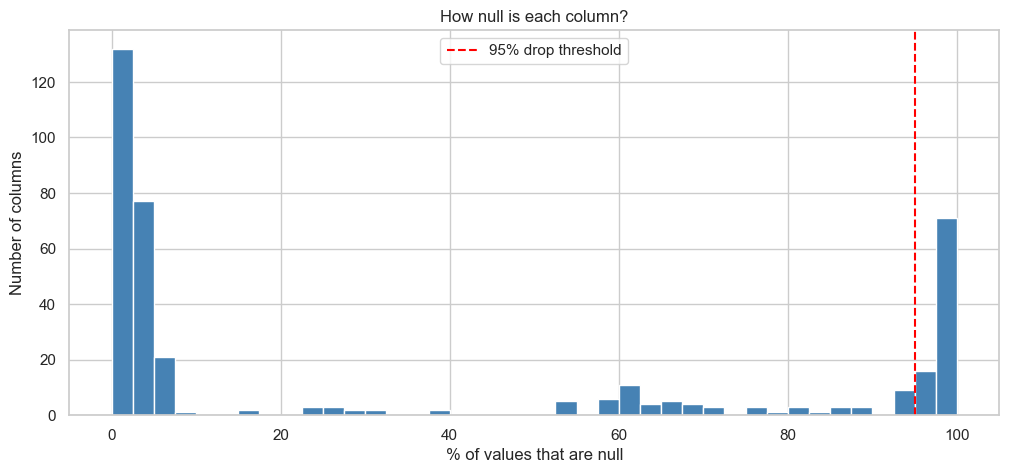

In [6]:
fig, ax = plt.subplots()
ax.hist(null_pct, bins=40, color='steelblue', edgecolor='white')
ax.axvline(95, color='red', linestyle='--', label='95% drop threshold')
ax.set_xlabel('% of values that are null')
ax.set_ylabel('Number of columns')
ax.set_title('How null is each column?')
ax.legend()
plt.show()

## Play types — what kinds of plays are in here?

Our model only cares about **run** and **pass** — the plays where a coordinator made a real call. Everything else (kickoffs, punts, field goals, penalties with no play) gets filtered out in notebook 02. This chart shows how much of the data that filtering keeps.

play_type
pass           60464
run            44814
no_play        14221
kickoff         8705
punt            6513
extra_point     3864
field_goal      3413
qb_kneel        1343
qb_spike         224


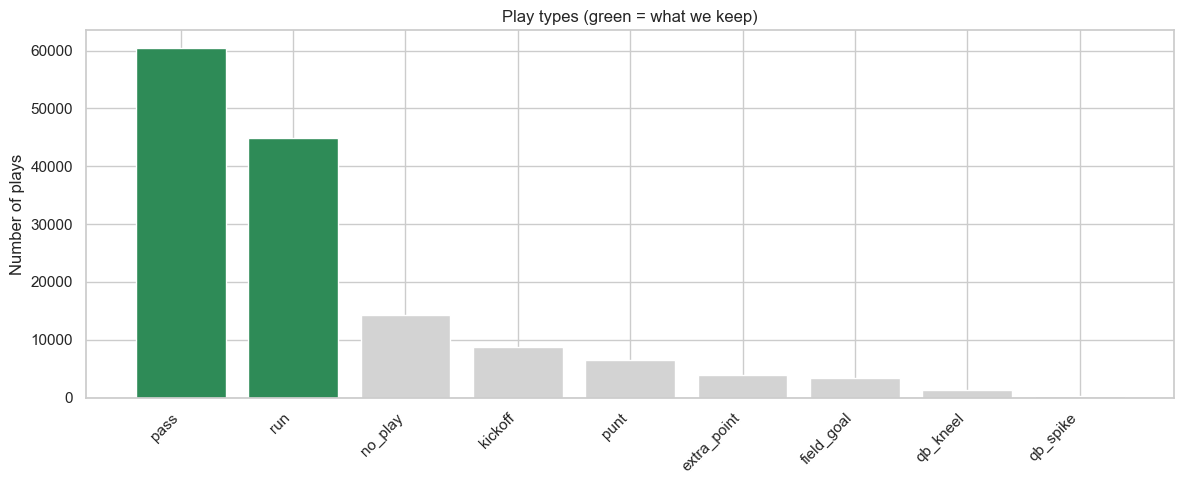

In [7]:
play_counts = df['play_type'].value_counts()
print(play_counts.to_string())

fig, ax = plt.subplots()
colors = ['seagreen' if p in ('run', 'pass') else 'lightgray' for p in play_counts.index]
ax.bar(play_counts.index, play_counts.values, color=colors)
ax.set_ylabel('Number of plays')
ax.set_title('Play types (green = what we keep)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## What we learned

- ~150k plays across 3 seasons, ~390 columns after merging in participation + FTN charting, with a big chunk of columns being 95%+ null (safe to drop).
- Participation and FTN data both attached to the large majority of plays in every season — enough to build formation, personnel, and play-concept features.
- Run + pass plays make up the majority of rows — plenty of training data.
- Key columns for our model are well-populated: down, distance, field position, score, clock, and EPA.

**Next:** open `02_clean_and_feature_engineer.ipynb` to clean this down, build the play-concept target, and build the rolling team-form features.

In [8]:
# Show every column for one random play
pd.set_option('display.max_rows', None)   # don't truncate the long output
sample = df.sample(1).T
sample

,6531
play_id,4071
game_id,2023_03_DAL_ARI
old_game_id,2023092410
home_team,ARI
away_team,DAL
season_type,REG
week,3
posteam,DAL
posteam_type,away
defteam,ARI


## What we learned

- ~150k plays across 3 seasons, ~390 columns, with a big chunk of columns being 95%+ null (safe to drop).
- Run + pass plays make up the majority of rows — plenty of training data.
- Key columns for our model are well-populated: down, distance, field position, score, clock, and EPA.

**Next:** open `02_clean_and_feature_engineer.ipynb` to clean this down and build the rolling team-form features.